In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yaml

In [2]:
config_path = "config_enact_raw.yaml"
title = "ENACT RAW"

In [3]:
with open(config_path, 'r') as f:
    try:
        setup_params = yaml.safe_load(f)
        # print(setup_params)
    except yaml.YAMLError as exc:
        print(exc)
        
logs_folder = setup_params["SETUP"]["log_folder"]

  Lowest CRPS = 0.178411 at N = 1024


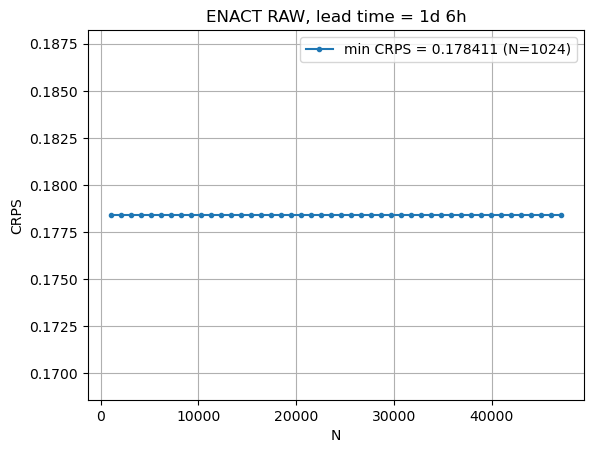

In [4]:
file_name = f"{logs_folder}/eval_validation.txt"
df = pd.read_csv(
    file_name,
    sep=r"\s+",
    header=3,
    # nrows=500,
    engine="python",
    on_bad_lines="warn",
)

df["CRPS"] = pd.to_numeric(df["CRPS"], errors="coerce")
df["N"] = pd.to_numeric(df["N"], errors="coerce")

min_idx = df["CRPS"].idxmin()
min_crps = df.loc[min_idx, "CRPS"]
best_N = int(df.loc[min_idx, "N"])

print(f"  Lowest CRPS = {min_crps:.6f} at N = {best_N}")

plt.plot(df["N"], df["CRPS"], '.-',
        label=f"min CRPS = {min_crps:.6f} (N={best_N})")

plt.grid()
plt.xlabel("N")
plt.ylabel("CRPS")
plt.title(f"{title}, lead time = 1d 6h")
plt.legend()
plt.show()